In [ ]:
import numpy as np
import pandas as pd
import os
import re
import sys
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebook" and (project_root.parent / "configs").exists():
    project_root = project_root.parent
elif not (project_root / "configs").exists() and (project_root.parent / "configs").exists():
    project_root = project_root.parent

sys.path.append(str(project_root))
from src.core_model.preprocess import apply_cleaning_pipeline

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
DATA = "data"
RAW = "raw"
SOFTWARE_DATA = "software_data"
CONFIGS = "configs"

settings_path = project_root / CONFIGS / "settings.yaml"
software_path = project_root / DATA / RAW / SOFTWARE_DATA / "Software.jsonl.gz"
meta_software_path = project_root / DATA / RAW / SOFTWARE_DATA / "meta_Software.jsonl.gz"

software = pd.read_json(software_path, lines=True, compression="gzip", nrows=10000)
meta_software = pd.read_json(meta_software_path, lines=True, compression="gzip", nrows=10000)
with open(settings_path, 'r') as f:
    cfg = yaml.safe_load(f)

In [29]:
software = pd.DataFrame(software)
meta_software = pd.DataFrame(meta_software)

In [30]:
cfg

{'software': {'text_cols': ['title', 'text'],
  'time_cols': ['timestamp'],
  'num_cols': ['rating'],
  'missing_values': {'drop_is_null': ['user_id'],
   'fill_constant': {'text': 'no_review', 'title': 'no_title'}},
  'numerical': {'nul_cols': 'rating',
   'non_negative': True,
   'min_rate': 1,
   'max_rate': 5}},
 'meta_software': {'text_cols': []}}

In [31]:
software

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1,malware,mcaffee IS malware,[],B07BFS3G7P,B0BQSK9QCF,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2019-07-03 19:37:12.076,0,False
1,5,Lots of Fun,I love playing tapped out because it is fun to...,[],B00CTQ6SIG,B00CTQ6SIG,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-02-16 20:58:56.000,0,True
2,5,Light Up The Dark,I love this flashlight app! It really illumin...,[],B0066WJLU6,B0066WJLU6,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2013-03-04 12:14:27.000,0,True
3,4,Fun game,One of my favorite games,[],B00KCYMAWK,B00KCYMAWK,AH6CATODIVPVUOJEWHRSRCSKAOHA,2019-06-20 20:10:28.662,0,True
4,4,I am not that good at it but my kids are,Cute game. I am not that good at it but my kid...,[],B00P1RK566,B00P1RK566,AEINY4XOINMMJCK5GZ3M6MMHBN6A,2014-12-11 00:19:56.000,0,True
...,...,...,...,...,...,...,...,...,...,...
9995,5,Alternative to Cutting the Cable Cord,I canceled cable and subscribed to YouTube TV ...,[],B07XF2P9KR,B07XF2P9KR,AENWO4JGIK3IBZYKKTAKJSHU3NNQ,2022-04-13 13:52:54.187,0,True
9996,1,Thumbs down,After being downloaded it wouldn't even open,[],B07856KTQF,B07856KTQF,AEM2STWGDZXSM43OAK55IXMG4BCQ,2022-02-17 01:36:16.105,0,True
9997,5,Having fun,I really like this game. The speed is perfect ...,[],B07JBN7KJ9,B07JBN7KJ9,AEM2STWGDZXSM43OAK55IXMG4BCQ,2021-10-28 21:14:45.187,15,True
9998,4,Love bingo,Really love playing this game. But such a sham...,[],B009WJNXAE,B009WJNXAE,AEM2STWGDZXSM43OAK55IXMG4BCQ,2021-09-30 22:43:02.058,21,True


In [32]:
software.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   rating             10000 non-null  int64         
 1   title              10000 non-null  str           
 2   text               10000 non-null  str           
 3   images             10000 non-null  object        
 4   asin               10000 non-null  str           
 5   parent_asin        10000 non-null  str           
 6   user_id            10000 non-null  str           
 7   timestamp          10000 non-null  datetime64[ms]
 8   helpful_vote       10000 non-null  int64         
 9   verified_purchase  10000 non-null  bool          
dtypes: bool(1), datetime64[ms](1), int64(2), object(1), str(5)
memory usage: 713.0+ KB


In [33]:
software.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='str')

In [34]:
software.describe()

,rating,timestamp,helpful_vote
count,10000.000000,10000,10000.000000
mean,3.848000,2017-06-05 20:47:15.745000,4.118500
min,1.000000,2000-08-08 07:23:31,0.000000
25%,3.000000,2015-05-30 22:09:50,0.000000
50%,5.000000,2017-08-30 04:47:52.939000,0.000000
75%,5.000000,2019-10-01 00:09:51.339000,3.000000
max,5.000000,2023-03-15 15:42:16.874000,797.000000
std,1.459558,NaN,18.591208


In [35]:
software.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [36]:
for col in software.columns:
    print(software[col].value_counts(), "\n")
    print("-----------------------------------")

rating
5    5142
4    1675
1    1385
3    1089
2     709
Name: count, dtype: int64 

-----------------------------------
title
Five Stars                               707
One Star                                 183
Four Stars                               179
Fun                                      137
Three Stars                              118
                                        ... 
Blink Outdoor Security Camera              1
Alternative to Cutting the Cable Cord      1
Thumbs down                                1
Having fun                                 1
Love bingo                                 1
Name: count, Length: 6584, dtype: int64 

-----------------------------------
text
Ok                                                                                                                                                                                                                                                                                                     

In [37]:
software_cfg = cfg["software"]
text_cols = software_cfg.get("text_cols")
text_cols

['title', 'text']

In [38]:
df = software.copy()
df = apply_cleaning_pipeline(df, software_cfg)

In [39]:
df

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,year timestamp,month,day,hour,weekday,quarter,is_weekend,is_month_end,days_since_ref
0,1,malware,mcaffee is malware,[],B07BFS3G7P,B0BQSK9QCF,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2019-07-03 19:37:12.076,0,False,2019,7,3,19,2,3,False,False,7415
1,5,lots of fun,i love playing tapped out because it is fun to...,[],B00CTQ6SIG,B00CTQ6SIG,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-02-16 20:58:56.000,0,True,2015,2,16,20,0,1,False,False,5817
2,5,light up the dark,i love this flashlight app it really illumina...,[],B0066WJLU6,B0066WJLU6,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2013-03-04 12:14:27.000,0,True,2013,3,4,12,0,1,False,False,5103
3,4,fun game,one of my favorite games,[],B00KCYMAWK,B00KCYMAWK,AH6CATODIVPVUOJEWHRSRCSKAOHA,2019-06-20 20:10:28.662,0,True,2019,6,20,20,3,2,False,False,7402
4,4,i am not that good at it but my kids are,cute game i am not that good at it but my kids...,[],B00P1RK566,B00P1RK566,AEINY4XOINMMJCK5GZ3M6MMHBN6A,2014-12-11 00:19:56.000,0,True,2014,12,11,0,3,4,False,False,5750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,5,alternative to cutting the cable cord,i canceled cable and subscribed to youtube tv ...,[],B07XF2P9KR,B07XF2P9KR,AENWO4JGIK3IBZYKKTAKJSHU3NNQ,2022-04-13 13:52:54.187,0,True,2022,4,13,13,2,2,False,False,8430
9996,1,thumbs down,after being downloaded it wouldnt even open,[],B07856KTQF,B07856KTQF,AEM2STWGDZXSM43OAK55IXMG4BCQ,2022-02-17 01:36:16.105,0,True,2022,2,17,1,3,1,False,False,8375
9997,5,having fun,i really like this game the speed is perfect s...,[],B07JBN7KJ9,B07JBN7KJ9,AEM2STWGDZXSM43OAK55IXMG4BCQ,2021-10-28 21:14:45.187,15,True,2021,10,28,21,3,4,False,False,8263
9998,4,love bingo,really love playing this game but such a shame...,[],B009WJNXAE,B009WJNXAE,AEM2STWGDZXSM43OAK55IXMG4BCQ,2021-09-30 22:43:02.058,21,True,2021,9,30,22,3,3,False,True,8235


In [40]:
meta_software

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Appstore for Android,Accupressure Guide,3.6,NaN,[All the pressing point has been explained wit...,[Acupressure technique is very ancient and ver...,0.00,[{'large': 'https://m.media-amazon.com/images/...,"[{'title': '', 'url': '', 'user_id': ''}]",mAppsguru,[],"{'Release Date': '2015', 'Date first listed on...",B00VRPSGEO,NaN
1,Appstore for Android,Ankylosaurus Fights Back - Smithsonian's Prehi...,4.0,NaN,[ENCOURAGE literacy skills with highlighted na...,[Join Ankylosaurus in this interactive book ap...,2.99,[{'large': 'https://m.media-amazon.com/images/...,"[{'title': '', 'url': '', 'user_id': ''}]","Oceanhouse Media, Inc",[],"{'Release Date': '2014', 'Date first listed on...",B00NWQXXHQ,NaN
2,Appstore for Android,Mahjong 2015,3.1,NaN,[Mahjong 2015 is a free solitaire matching gam...,[Mahjong 2015 is a free solitaire matching gam...,0.00,[{'large': 'https://m.media-amazon.com/images/...,"[{'title': '', 'url': '', 'user_id': ''}]",sophiathach,[],"{'Release Date': '2014', 'Date first listed on...",B00RFKP6AC,NaN
3,Appstore for Android,Jewels Brick Breakout,4.2,NaN,"[Game Features:, - Intuitive touch controls wi...",[Jewels Brick Breakout is a glowing jewels bri...,0.00,[{'large': 'https://m.media-amazon.com/images/...,"[{'title': '', 'url': '', 'user_id': ''}]",Bad Chicken,[],"{'Release Date': '2015', 'Date first listed on...",B00SP2QU0E,NaN
4,Appstore for Android,Traffic Police: Off-Road Cub,3.3,NaN,"[In this game you will find:, - Killer police ...",[Become the best road police officer in Cube C...,0.00,[{'large': 'https://m.media-amazon.com/images/...,"[{'title': '', 'url': '', 'user_id': ''}]",Dast 2 For Metro,[],"{'Release Date': '2016', 'Date first listed on...",B01DZIT64O,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Appstore for Android,Vision Board PRO,3.0,5.0,"[311 wishes symbols from 18 categories;, 385 r...",[Lose weight? Make lots of money? Reach a goal...,8.00,[{'large': 'https://m.media-amazon.com/images/...,"[{'title': '', 'url': 'https://images-na.ssl-i...",Astraport Inc.,[],"{'Release Date': '2012', 'Date first listed on...",B007IWUUZ8,NaN
9996,Appstore for Android,1st - 2nd Grade Fiction Reading Comprehension,3.2,6.0,"[Reading Comprehension, Teaches Vocabulary and...",[This fiction reading comprehension app has tw...,2.99,[{'large': 'https://m.media-amazon.com/images/...,"[{'title': '', 'url': '', 'user_id': ''}]",Abitalk,[],"{'Release Date': '2014', 'Date first listed on...",B00PBIKPJ2,NaN
9997,Appstore for Android,Extreme Bright Free Flashlight,3.2,99.0,"[Mobile device becomes a flashlight, Large On/...",[Get the Brightest Free of charge Flashlight o...,0.00,[{'large': 'https://m.media-amazon.com/images/...,"[{'title': '', 'url': '', 'user_id': ''}]",WACKIAPPS,[],"{'Release Date': '2011', 'Date first listed on...",B00655FPU4,NaN
9998,Appstore for Android,GialloZafferano Italian and World Recipes,4.2,218.0,[learn how to cook with videos and easy step b...,"[*** NOW AD-FREE UNTIL MARCH, ONLY ON AMAZON A...",0.00,[{'large': 'https://m.media-amazon.com/images/...,"[{'title': '', 'url': '', 'user_id': ''}]",Banzai,[],"{'Release Date': '2012', 'Date first listed on...",B008SD6KAU,NaN


In [41]:
meta_software.columns

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together'],
      dtype='str')

# DATA VISUALISATION

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9060\3452035064.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'rating', palette = 'viridis')


Text(0, 0.5, 'Số lượng')

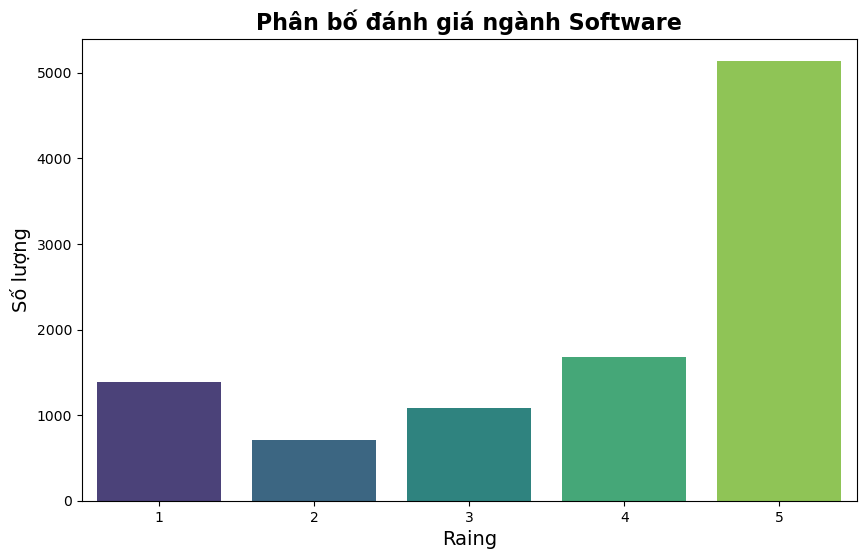

In [21]:
df = software
fig = plt.figure(figsize=(10, 6))
sns.countplot(data = df, x = 'rating', palette = 'viridis')
plt.title("Phân bố đánh giá ngành Software", fontsize = 16, fontweight = 'bold')
plt.xlabel("Raing", fontsize = 14)
plt.ylabel("Số lượng", fontsize = 14)

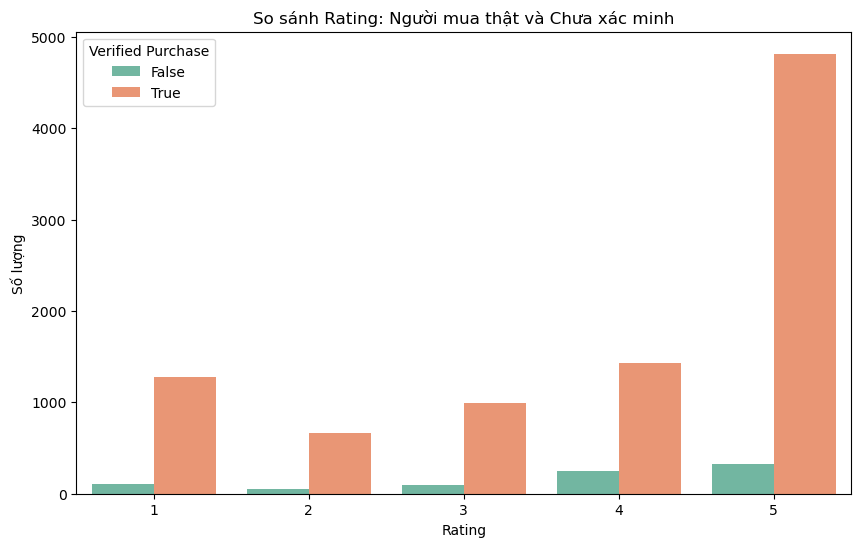

In [22]:
fig = plt.figure(figsize = (10, 6))
sns.countplot(data= software, x= 'rating', hue= 'verified_purchase', palette= 'Set2')
plt.title("So sánh Rating: Người mua thật và Chưa xác minh")
plt.xlabel("Rating")
plt.ylabel("Số lượng")
plt.legend(title= "Verified Purchase")
plt.show()

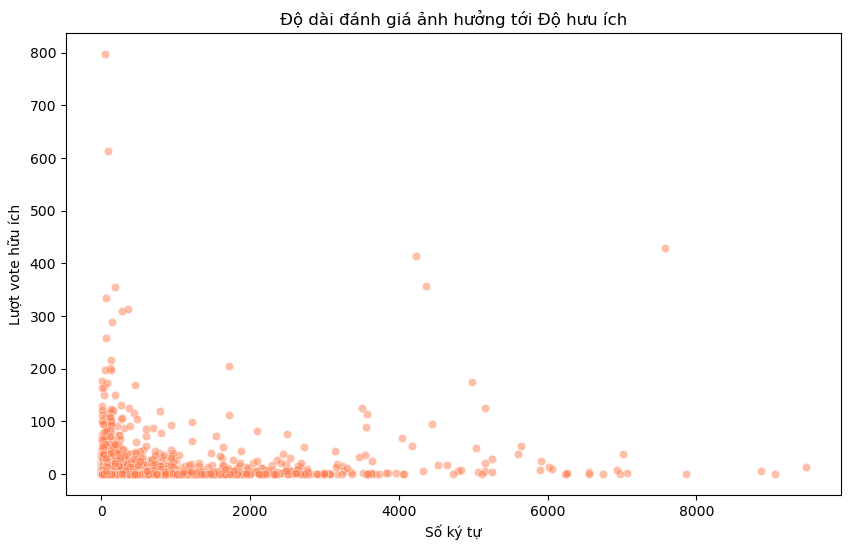

In [25]:
df_reviews = software.copy()
df_reviews["review_length"] = df_reviews['text'].astype(str).apply(len)
fig = plt.figure(figsize= (10, 6))
sns.scatterplot(data = df_reviews, x = 'review_length', y = 'helpful_vote', alpha= 0.5, color = 'coral')
plt.title("Độ dài đánh giá ảnh hưởng tới Độ hưu ích")
plt.xlabel("Số ký tự")
plt.ylabel("Lượt vote hữu ích")
plt.show()